In [ ]:


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "Results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


RESULTS_FOLDER = (
    PROJECT_ROOT
    / "Results"
)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_FOLDER:", RESULTS_FOLDER)

PROJECT_ROOT: c:\Users\srush\Desktop\Multi agent coordination
RESULTS_FOLDER: c:\Users\srush\Desktop\Multi agent coordination\Results


In [ ]:


quality_details_path = (
    RESULTS_FOLDER
    / "recommendation_quality_details.csv"
)

quality_summary_path = (
    RESULTS_FOLDER
    / "recommendation_quality_summary.csv"
)

final_grounding_path = (
    RESULTS_FOLDER
    / "final_recommendation_grounding_summary.csv"
)


quality_df = pd.read_csv(
    quality_details_path
)

quality_summary_df = pd.read_csv(
    quality_summary_path
)

final_grounding_df = pd.read_csv(
    final_grounding_path
)


print(
    "Quality detail rows:",
    len(quality_df)
)

print(
    "Quality summary rows:",
    len(quality_summary_df)
)

print(
    "Final grounding rows:",
    len(final_grounding_df)
)


display(
    final_grounding_df
)

Quality detail rows: 156
Quality summary rows: 3
Final grounding rows: 3


,system,total_queries,recommendations_made,recommendation_rate,grounded_recommendation_rate,partial_grounding_rate,hallucination_rate
0,Single Agent,15,13,0.8667,0.6923,0.1538,0.1538
1,Multi-Agent Without Coordination,15,15,1.0000,0.4667,0.2000,0.3333
2,Coordinated Multi-Agent,15,12,0.8000,0.7500,0.2500,0.0000


In [ ]:

print(
    """
Operational definitions used in this experiment:

Grounded:
The final recommended product satisfies the product type,
brand/budget hard constraints where verifiable, and the
requested features are fully supported by available Amazon
product evidence.

Partially Grounded:
The recommendation satisfies hard constraints but only some
requested features are supported.

Hallucinated / Unsupported:
The recommendation violates a hard constraint OR has no
support for the requested feature requirements.

No Recommendation:
The system correctly abstains when no sufficiently supported
product is available.
"""
)


Operational definitions used in this experiment:

Grounded:
The final recommended product satisfies the product type,
brand/budget hard constraints where verifiable, and the
requested features are fully supported by available Amazon
product evidence.

Partially Grounded:
The recommendation satisfies hard constraints but only some
requested features are supported.

Hallucinated / Unsupported:
The recommendation violates a hard constraint OR has no
support for the requested feature requirements.

No Recommendation:
The system correctly abstains when no sufficiently supported
product is available.



In [ ]:


recommended_products_df = (
    quality_df[
        quality_df[
            "is_recommended"
        ] == True
    ]
    .copy()
)


display(
    recommended_products_df[
        [
            "system",
            "test_id",
            "user_query",
            "parent_asin",
            "product_type_match",
            "brand_match",
            "budget_match",
            "feature_status",
            "feature_match_ratio",
            "support_level"
        ]
    ]
)

,system,test_id,user_query,parent_asin,product_type_match,brand_match,budget_match,feature_status,feature_match_ratio,support_level
0,Single Agent,1,Recommend a Samsung phone with a good camera a...,B09X9FC88M,True,True,NaN,full_match,1.000000,grounded
5,Single Agent,2,I want an Apple phone with excellent camera qu...,B078WZX9LD,True,True,NaN,full_match,1.000000,grounded
8,Single Agent,3,Suggest a Google phone with fast performance.,B09NP4C1MF,True,True,NaN,no_match,0.000000,unsupported
11,Single Agent,4,Recommend a Samsung phone under 300 with a goo...,B07QH32PCY,True,True,True,full_match,1.000000,grounded
14,Single Agent,5,Recommend a smartphone under 250 with long bat...,B0995SX8X8,True,True,NaN,full_match,1.000000,grounded
19,Single Agent,6,Recommend a phone with a great camera.,B01LZ8516T,True,True,NaN,full_match,1.000000,grounded
24,Single Agent,7,Recommend a phone with long battery life.,B0995SX8X8,True,True,NaN,full_match,1.000000,grounded
26,Single Agent,8,Suggest a smartphone for gaming.,B09L4QQCN2,True,True,NaN,full_match,1.000000,grounded
28,Single Agent,9,"Recommend a Samsung phone with a good camera, ...",B09X9FC88M,True,True,NaN,partial_match,0.666667,partial
33,Single Agent,10,Recommend an Apple phone with a good camera an...,B078WZX9LD,True,True,NaN,full_match,1.000000,grounded


In [ ]:


recommended_products_df = (
    quality_df[
        quality_df[
            "is_recommended"
        ] == True
    ]
    .copy()
)


display(
    recommended_products_df[
        [
            "system",
            "test_id",
            "user_query",
            "parent_asin",
            "product_type_match",
            "brand_match",
            "budget_match",
            "feature_status",
            "feature_match_ratio",
            "support_level"
        ]
    ]
)

,system,test_id,user_query,parent_asin,product_type_match,brand_match,budget_match,feature_status,feature_match_ratio,support_level
0,Single Agent,1,Recommend a Samsung phone with a good camera a...,B09X9FC88M,True,True,NaN,full_match,1.000000,grounded
5,Single Agent,2,I want an Apple phone with excellent camera qu...,B078WZX9LD,True,True,NaN,full_match,1.000000,grounded
8,Single Agent,3,Suggest a Google phone with fast performance.,B09NP4C1MF,True,True,NaN,no_match,0.000000,unsupported
11,Single Agent,4,Recommend a Samsung phone under 300 with a goo...,B07QH32PCY,True,True,True,full_match,1.000000,grounded
14,Single Agent,5,Recommend a smartphone under 250 with long bat...,B0995SX8X8,True,True,NaN,full_match,1.000000,grounded
19,Single Agent,6,Recommend a phone with a great camera.,B01LZ8516T,True,True,NaN,full_match,1.000000,grounded
24,Single Agent,7,Recommend a phone with long battery life.,B0995SX8X8,True,True,NaN,full_match,1.000000,grounded
26,Single Agent,8,Suggest a smartphone for gaming.,B09L4QQCN2,True,True,NaN,full_match,1.000000,grounded
28,Single Agent,9,"Recommend a Samsung phone with a good camera, ...",B09X9FC88M,True,True,NaN,partial_match,0.666667,partial
33,Single Agent,10,Recommend an Apple phone with a good camera an...,B078WZX9LD,True,True,NaN,full_match,1.000000,grounded


In [ ]:


outcome_rows = []


systems = [
    "Single Agent",
    "Multi-Agent Without Coordination",
    "Coordinated Multi-Agent"
]


for system_name in systems:

    system_recs = (
        recommended_products_df[
            recommended_products_df[
                "system"
            ] == system_name
        ]
    )


    grounded_count = (
        system_recs[
            "support_level"
        ]
        .eq(
            "grounded"
        )
        .sum()
    )


    partial_count = (
        system_recs[
            "support_level"
        ]
        .eq(
            "partial"
        )
        .sum()
    )


    unsupported_count = (
        system_recs[
            "support_level"
        ]
        .eq(
            "unsupported"
        )
        .sum()
    )


    recommendation_count = len(
        system_recs
    )


    outcome_rows.append(
        {
            "system":
                system_name,

            "recommendations_made":
                recommendation_count,

            "grounded_count":
                grounded_count,

            "partial_count":
                partial_count,

            "unsupported_count":
                unsupported_count
        }
    )


outcome_counts_df = pd.DataFrame(
    outcome_rows
)


display(
    outcome_counts_df
)

,system,recommendations_made,grounded_count,partial_count,unsupported_count
0,Single Agent,13,9,2,2
1,Multi-Agent Without Coordination,15,7,3,5
2,Coordinated Multi-Agent,12,9,3,0


In [ ]:


total_queries = 15


outcome_counts_df[
    "total_queries"
] = total_queries


outcome_counts_df[
    "no_recommendation_count"
] = (
    total_queries
    - outcome_counts_df[
        "recommendations_made"
    ]
)


outcome_counts_df[
    "recommendation_rate"
] = (
    outcome_counts_df[
        "recommendations_made"
    ]
    / total_queries
)


outcome_counts_df[
    "abstention_rate"
] = (
    outcome_counts_df[
        "no_recommendation_count"
    ]
    / total_queries
)


display(
    outcome_counts_df
)

,system,recommendations_made,grounded_count,partial_count,unsupported_count,total_queries,no_recommendation_count,recommendation_rate,abstention_rate
0,Single Agent,13,9,2,2,15,2,0.866667,0.133333
1,Multi-Agent Without Coordination,15,7,3,5,15,0,1.000000,0.000000
2,Coordinated Multi-Agent,12,9,3,0,15,3,0.800000,0.200000


In [ ]:

hallucination_rows = []


for _, row in (
    outcome_counts_df.iterrows()
):

    recommendations_made = int(
        row[
            "recommendations_made"
        ]
    )


    grounded_count = int(
        row[
            "grounded_count"
        ]
    )

    partial_count = int(
        row[
            "partial_count"
        ]
    )

    unsupported_count = int(
        row[
            "unsupported_count"
        ]
    )


    if recommendations_made > 0:

        grounded_rate = (
            grounded_count
            / recommendations_made
        )

        partial_rate = (
            partial_count
            / recommendations_made
        )

        hallucination_rate = (
            unsupported_count
            / recommendations_made
        )

    else:

        grounded_rate = 0.0
        partial_rate = 0.0
        hallucination_rate = 0.0


    hallucination_rows.append(
        {
            "system":
                row["system"],

            "total_queries":
                int(
                    row[
                        "total_queries"
                    ]
                ),

            "recommendations_made":
                recommendations_made,

            "recommendation_rate":
                round(
                    row[
                        "recommendation_rate"
                    ],
                    4
                ),

            "abstention_rate":
                round(
                    row[
                        "abstention_rate"
                    ],
                    4
                ),

            "grounded_recommendation_rate":
                round(
                    grounded_rate,
                    4
                ),

            "partial_grounding_rate":
                round(
                    partial_rate,
                    4
                ),

            "hallucination_rate":
                round(
                    hallucination_rate,
                    4
                )
        }
    )


hallucination_summary_df = pd.DataFrame(
    hallucination_rows
)


display(
    hallucination_summary_df
)

,system,total_queries,recommendations_made,recommendation_rate,abstention_rate,grounded_recommendation_rate,partial_grounding_rate,hallucination_rate
0,Single Agent,15,13,0.8667,0.1333,0.6923,0.1538,0.1538
1,Multi-Agent Without Coordination,15,15,1.0000,0.0000,0.4667,0.2000,0.3333
2,Coordinated Multi-Agent,15,12,0.8000,0.2000,0.7500,0.2500,0.0000


In [ ]:


query_level_df = (
    recommended_products_df[
        [
            "system",
            "test_id",
            "user_query",
            "parent_asin",
            "support_level",
            "feature_status",
            "feature_match_ratio",
            "product_type_match",
            "brand_match",
            "budget_match"
        ]
    ]
    .copy()
)


query_level_df[
    "is_hallucinated"
] = (
    query_level_df[
        "support_level"
    ]
    == "unsupported"
)


query_level_df[
    "is_grounded"
] = (
    query_level_df[
        "support_level"
    ]
    == "grounded"
)


display(
    query_level_df.sort_values(
        [
            "test_id",
            "system"
        ]
    )
)

,system,test_id,user_query,parent_asin,support_level,feature_status,feature_match_ratio,product_type_match,brand_match,budget_match,is_hallucinated,is_grounded
111,Coordinated Multi-Agent,1,Recommend a Samsung phone with a good camera a...,B0B1QXHB7L,grounded,full_match,1.000000,True,True,NaN,False,True
52,Multi-Agent Without Coordination,1,Recommend a Samsung phone with a good camera a...,B0B1QXHB7L,grounded,full_match,1.000000,True,True,NaN,False,True
0,Single Agent,1,Recommend a Samsung phone with a good camera a...,B09X9FC88M,grounded,full_match,1.000000,True,True,NaN,False,True
116,Coordinated Multi-Agent,2,I want an Apple phone with excellent camera qu...,B00ORZVW42,grounded,full_match,1.000000,True,True,NaN,False,True
57,Multi-Agent Without Coordination,2,I want an Apple phone with excellent camera qu...,B00ORZVW42,grounded,full_match,1.000000,True,True,NaN,False,True
5,Single Agent,2,I want an Apple phone with excellent camera qu...,B078WZX9LD,grounded,full_match,1.000000,True,True,NaN,False,True
58,Multi-Agent Without Coordination,3,Suggest a Google phone with fast performance.,B01M27MVQI,unsupported,no_match,0.000000,True,True,NaN,True,False
8,Single Agent,3,Suggest a Google phone with fast performance.,B09NP4C1MF,unsupported,no_match,0.000000,True,True,NaN,True,False
117,Coordinated Multi-Agent,4,Recommend a Samsung phone under 300 with a goo...,B09C6N8P6Y,grounded,full_match,1.000000,True,True,True,False,True
60,Multi-Agent Without Coordination,4,Recommend a Samsung phone under 300 with a goo...,B09C6N8P6Y,grounded,full_match,1.000000,True,True,True,False,True


In [ ]:


hallucinated_cases_df = (
    query_level_df[
        query_level_df[
            "is_hallucinated"
        ] == True
    ]
    .copy()
)


print(
    "Total hallucinated final recommendations:",
    len(
        hallucinated_cases_df
    )
)


display(
    hallucinated_cases_df
)

Total hallucinated final recommendations: 7


,system,test_id,user_query,parent_asin,support_level,feature_status,feature_match_ratio,product_type_match,brand_match,budget_match,is_hallucinated,is_grounded
8,Single Agent,3,Suggest a Google phone with fast performance.,B09NP4C1MF,unsupported,no_match,0.0,True,True,NaN,True,False
42,Single Agent,12,I need something good for photography.,B0BTYKDN5L,unsupported,full_match,1.0,False,True,NaN,True,False
58,Multi-Agent Without Coordination,3,Suggest a Google phone with fast performance.,B01M27MVQI,unsupported,no_match,0.0,True,True,NaN,True,False
65,Multi-Agent Without Coordination,5,Recommend a smartphone under 250 with long bat...,B0B74J524C,unsupported,no_match,0.0,True,True,True,True,False
75,Multi-Agent Without Coordination,7,Recommend a phone with long battery life.,B07K9PR1H5,unsupported,no_match,0.0,True,True,NaN,True,False
103,Multi-Agent Without Coordination,13,Recommend an Apple phone with stylus support.,B00ORZVW42,unsupported,no_match,0.0,True,True,NaN,True,False
109,Multi-Agent Without Coordination,15,Recommend a Nokia phone with an 8K camera and ...,B003X26SLM,unsupported,no_match,0.0,True,True,NaN,True,False


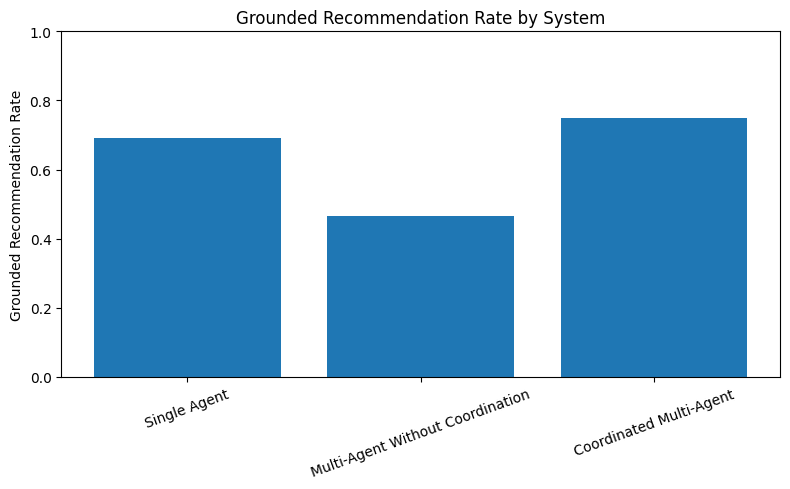

In [ ]:


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    hallucination_summary_df[
        "system"
    ],
    hallucination_summary_df[
        "grounded_recommendation_rate"
    ]
)

plt.ylabel(
    "Grounded Recommendation Rate"
)

plt.title(
    "Grounded Recommendation Rate by System"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

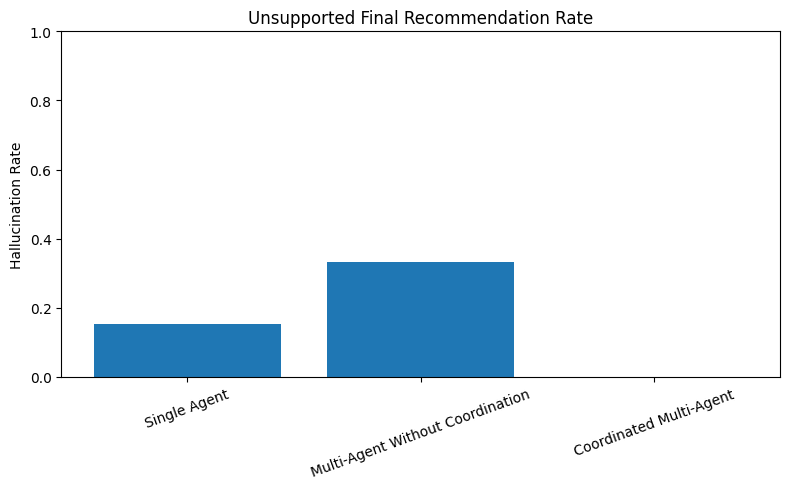

In [ ]:


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    hallucination_summary_df[
        "system"
    ],
    hallucination_summary_df[
        "hallucination_rate"
    ]
)

plt.ylabel(
    "Hallucination Rate"
)

plt.title(
    "Unsupported Final Recommendation Rate"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

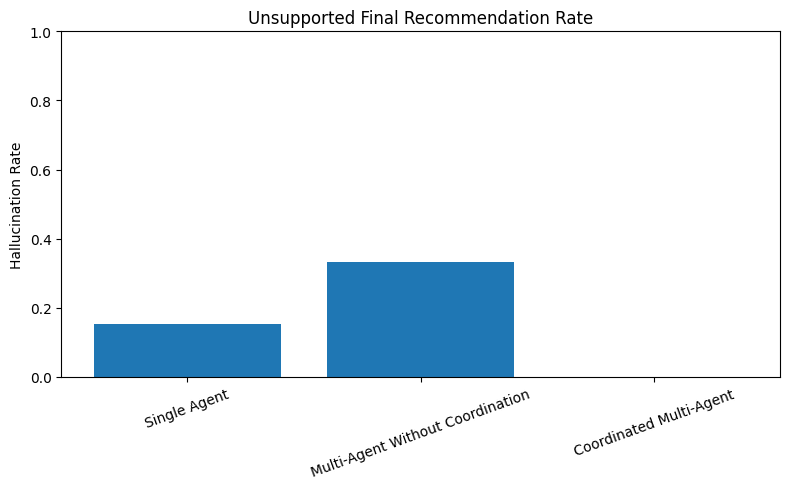

In [ ]:


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    hallucination_summary_df[
        "system"
    ],
    hallucination_summary_df[
        "hallucination_rate"
    ]
)

plt.ylabel(
    "Hallucination Rate"
)

plt.title(
    "Unsupported Final Recommendation Rate"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

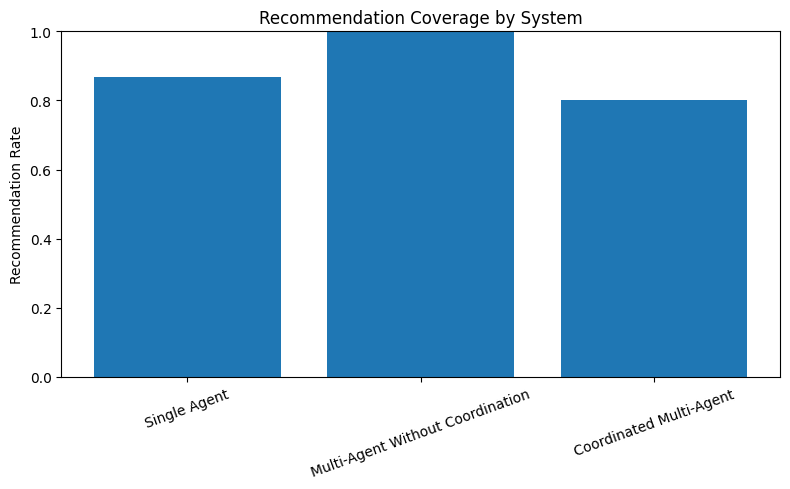

In [ ]:


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    hallucination_summary_df[
        "system"
    ],
    hallucination_summary_df[
        "recommendation_rate"
    ]
)

plt.ylabel(
    "Recommendation Rate"
)

plt.title(
    "Recommendation Coverage by System"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

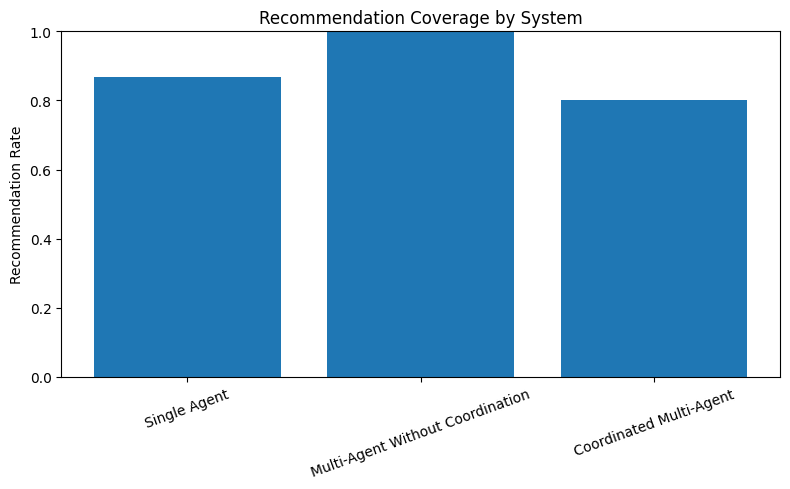

In [ ]:

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    hallucination_summary_df[
        "system"
    ],
    hallucination_summary_df[
        "recommendation_rate"
    ]
)

plt.ylabel(
    "Recommendation Rate"
)

plt.title(
    "Recommendation Coverage by System"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()